In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, precision_recall_curve, average_precision_score)

# Görsel ayarlar
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

In [20]:
# Veri setini okuma
df = pd.read_csv('Istanbul_Final_Analiz_Verisi.csv')

# Özellik seçimi
features = ['İlçe', 'Maks_Sıcaklik_C', 'Toplam_Yağış_mm', 'Maks_Rüzgar_Hızı_kmh', 'average_traffic_index', 'Ay', 'Durum']
target = 'Sağlık_Risk_Durumu'

X = df[features].copy()
y = df[target].copy()

# One-Hot Encoding ve Label Encoding
X_encoded = pd.get_dummies(X, columns=['İlçe', 'Durum'], drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Eğitim ve Test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Veri seti başarıyla hazırlandı. Toplam örnek sayısı: {len(df)}")

Veri seti başarıyla hazırlandı. Toplam örnek sayısı: 16035


In [21]:
# Overfitting'i engellemek için budanmış (pruned) model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

# Tahminler
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)

# Raporlama
print("--- MODEL PERFORMANS ÖZETİ ---")
print(f"Genel Doğruluk (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}")
print(f"F1-Skoru (Weighted): %{f1_score(y_test, y_pred, average='weighted') * 100:.2f}")
print("-" * 30)
print("DETAYLI SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, y_pred, target_names=class_names))

--- MODEL PERFORMANS ÖZETİ ---
Genel Doğruluk (Accuracy): %94.29
F1-Skoru (Weighted): %95.20
------------------------------
DETAYLI SINIFLANDIRMA RAPORU:
                                   precision    recall  f1-score   support

             Düşük Risk (Güvenli)       1.00      0.95      0.98      1540
Orta Risk (Hassas Gruplar Dikkat)       0.95      0.95      0.95      1425
          Yüksek Risk (Sağlıksız)       0.86      0.83      0.84       227
      Çok Yüksek Risk (Tehlikeli)       0.14      0.93      0.25        15

                         accuracy                           0.94      3207
                        macro avg       0.74      0.92      0.75      3207
                     weighted avg       0.96      0.94      0.95      3207



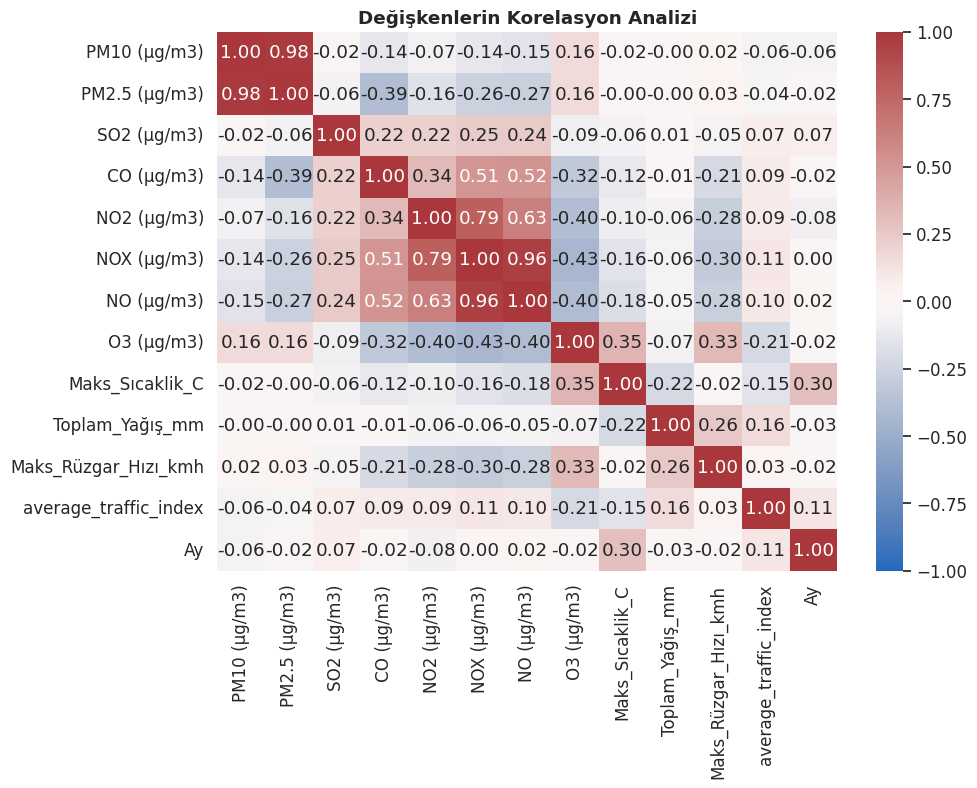

In [22]:
# 1. Korelasyon Matrisi
plt.figure(figsize=(10, 7))
korelasyon = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(korelasyon, annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
plt.title('Değişkenlerin Korelasyon Analizi', fontweight='bold')
plt.show()

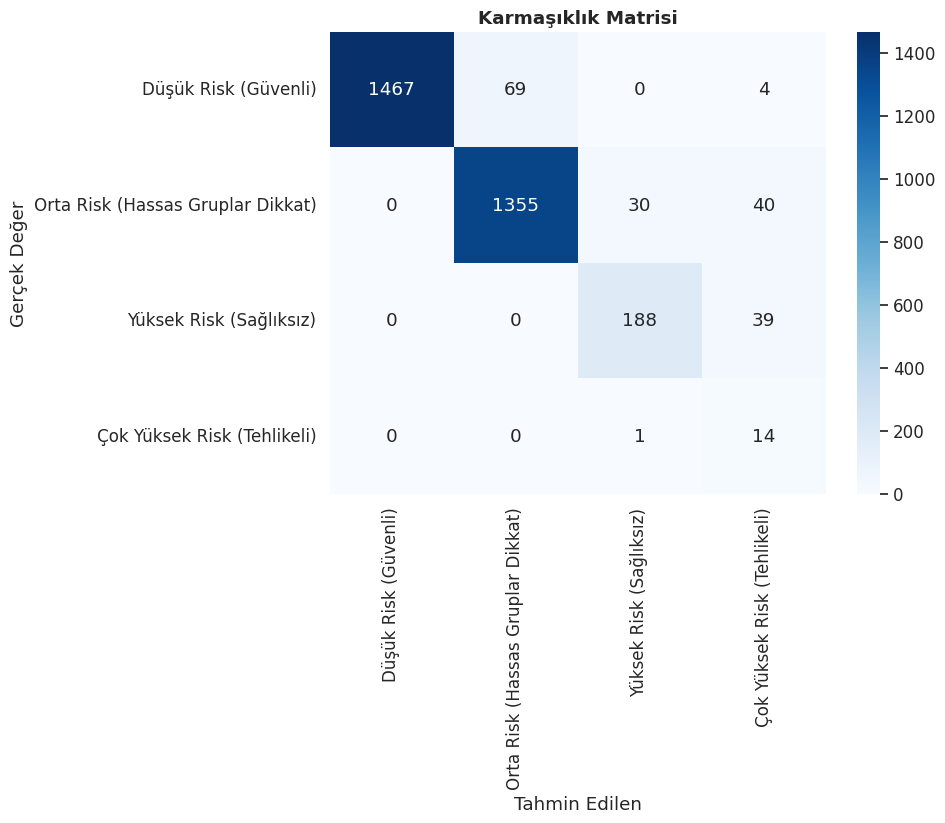

In [23]:
# 2. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Karmaşıklık Matrisi', fontweight='bold')
plt.show()

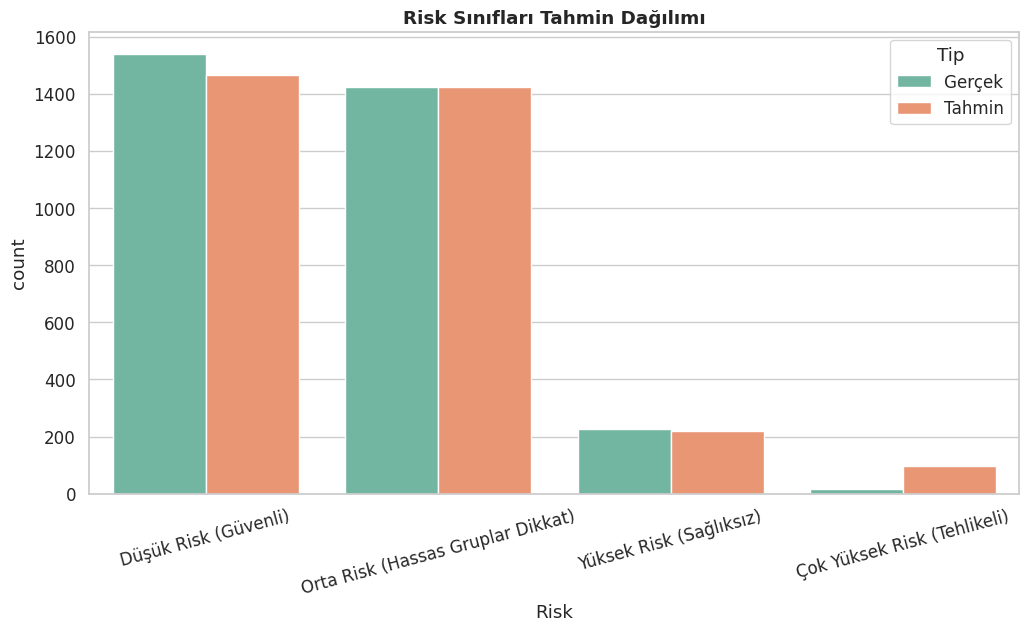

In [24]:
# 3. Gerçek vs Tahmin Dağılımı
res_df = pd.DataFrame({
    'Risk': np.concatenate([le.inverse_transform(y_test), le.inverse_transform(y_pred)]),
    'Tip': ['Gerçek'] * len(y_test) + ['Tahmin'] * len(y_pred)
})
order = res_df[res_df['Tip'] == 'Gerçek']['Risk'].value_counts().index.tolist()

plt.figure(figsize=(12, 6))
sns.countplot(data=res_df, x='Risk', hue='Tip', order=order, palette='Set2')
plt.title('Risk Sınıfları Tahmin Dağılımı', fontweight='bold')
plt.xticks(rotation=15)
plt.show()

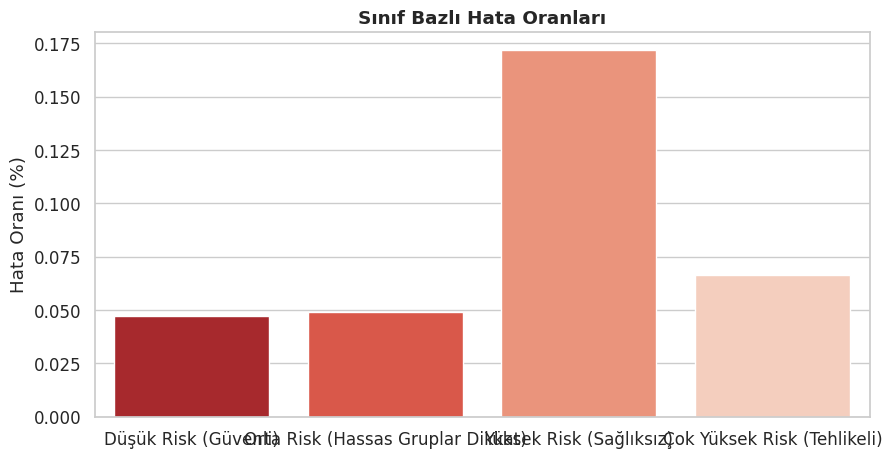

In [25]:
# 4. Hata Oranları
plt.figure(figsize=(10, 5))
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
hata_oranlari = 1 - np.diag(cm_norm)
sns.barplot(x=class_names, y=hata_oranlari, palette='Reds_r')
plt.title('Sınıf Bazlı Hata Oranları', fontweight='bold')
plt.ylabel('Hata Oranı (%)')
plt.show()

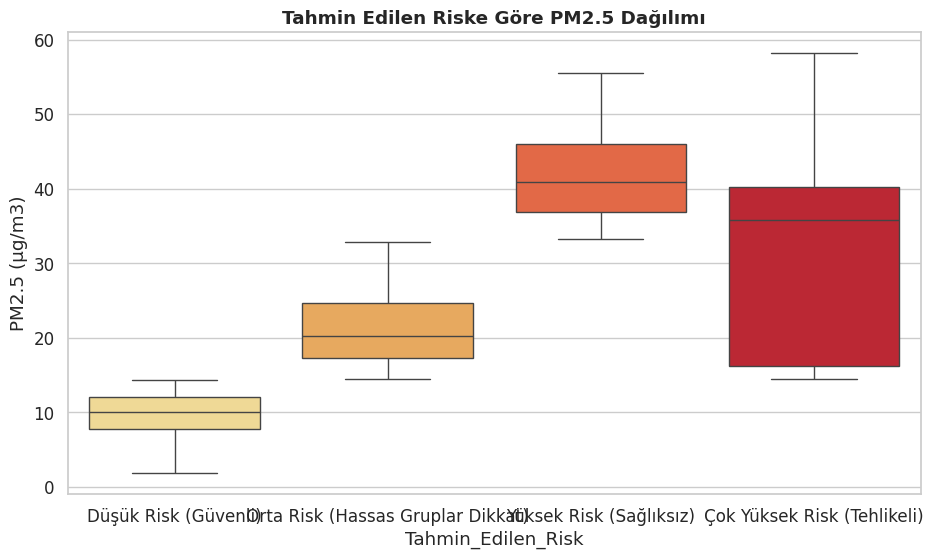

In [26]:
test_data = df.loc[X_test.index].copy()
test_data['Tahmin_Edilen_Risk'] = le.inverse_transform(y_pred)
risk_siralamasi = ['Düşük Risk (Güvenli)', 'Orta Risk (Hassas Gruplar Dikkat)', 'Yüksek Risk (Sağlıksız)', 'Çok Yüksek Risk (Tehlikeli)']
mevcut_riskler = [r for r in risk_siralamasi if r in test_data['Tahmin_Edilen_Risk'].unique()]

# 6. tahmin edilen riske göre pm2.5 dağılımı
plt.figure(figsize=(11, 6))
sns.boxplot(data=test_data, x='Tahmin_Edilen_Risk', y='PM2.5 (µg/m3)', order=mevcut_riskler, palette='YlOrRd')
plt.title('Tahmin Edilen Riske Göre PM2.5 Dağılımı', fontweight='bold')
plt.show()

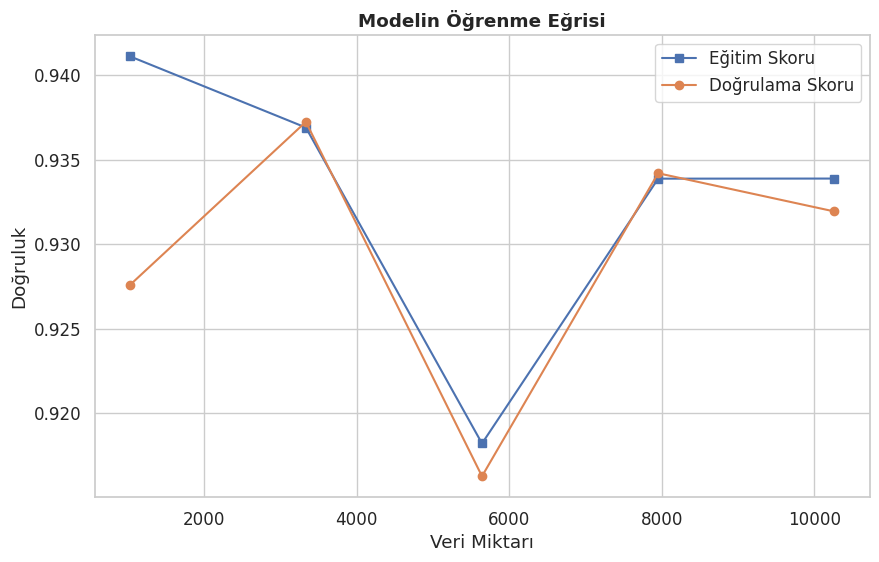

In [27]:
# 7. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(estimator=model, X=X_train_scaled, y=y_train, cv=5)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Eğitim Skoru', marker='s')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Doğrulama Skoru', marker='o')
plt.title('Modelin Öğrenme Eğrisi', fontweight='bold')
plt.xlabel('Veri Miktarı')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

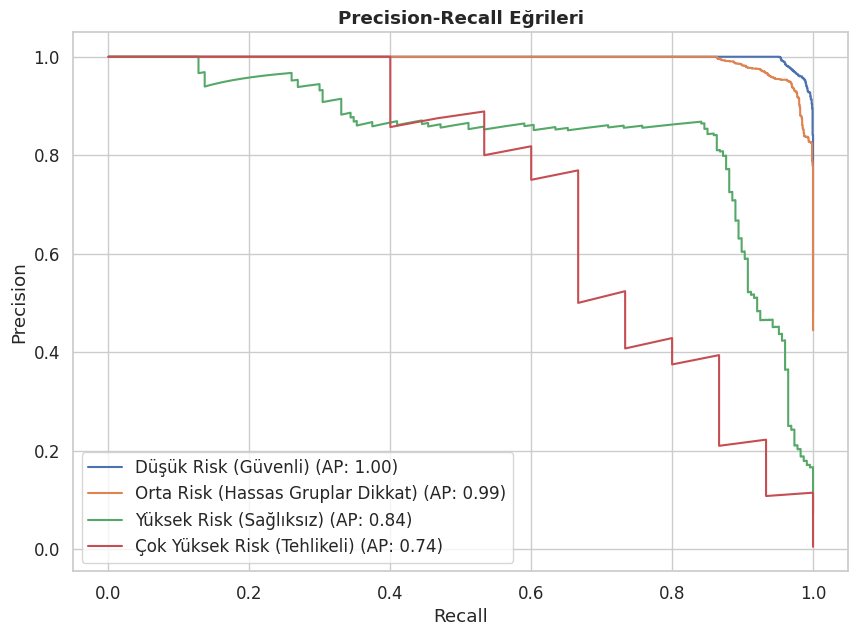

In [28]:
# 8. Precision-Recall
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
plt.figure(figsize=(10, 7))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f'{class_names[i]} (AP: {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Eğrileri', fontweight='bold')
plt.legend()
plt.show()